# Day 37 : XGBoost

---

## Objectives:

 - Understand **what XGBoost is** and how it works.
 - Learn **why XGBoost is powerful** in practical applications.
 - Implement **XGBoost for Classification and Regression** using real-world datasets.
 - Create **robust visualizations** to interpret XGBoost model performance.
 - Gain insights into an **industry-standard machine learning technique**.

 ---

 ## 1. Introduction to XGBoost

## What is XGBoost?
 - XGBoost (Extreme Gradient Boosting) is an efficient and scalable implementation of gradient boosting framework.
 - It uses ensemble learning by combining multiple weak learners (usually decision trees) to build a strong model.

## Why is XGBoost Powerful?
 ✅ Regularization to reduce overfitting<br>
 ✅ Built-in handling of missing data<br>
 ✅ Parallel and distributed computing<br>
 ✅ Cross-validation support<br>
 ✅ Feature importance visualization<br>
 ✅ Works well with imbalanced datasets<br>

 ---

 ## 2. Dataset Overview

 For classification: **Heart Disease UCI Dataset**
 For regression: **California Housing Dataset**

 ---

 ## 3. Imports and Setup

 ---

In [5]:
#Import libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from xgboost import XGBClassifier, XGBRegressor, plot_importance
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score, mean_absolute_error, mean_squared_error, r2_score
from sklearn.datasets import fetch_california_housing
import warnings 
warnings.filterwarnings('ignore')

In [3]:
#!pip install xgboost

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.0/2.0 MB 1.9 MB/s eta 0:00:00a 0:00:01


---

## 4. Classification with XGBoost (Heart Disease Dataset)

---


In [6]:
#Load Classification dataset
heart_df = pd.read_csv('heart.csv')

In [8]:
heart_df

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,63,1,3,145,233,1,0,150,0,2.3,0,0,1,1
1,37,1,2,130,250,0,1,187,0,3.5,0,0,2,1
2,41,0,1,130,204,0,0,172,0,1.4,2,0,2,1
3,56,1,1,120,236,0,1,178,0,0.8,2,0,2,1
4,57,0,0,120,354,0,1,163,1,0.6,2,0,2,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
298,57,0,0,140,241,0,1,123,1,0.2,1,0,3,0
299,45,1,3,110,264,0,1,132,0,1.2,1,0,3,0
300,68,1,0,144,193,1,1,141,0,3.4,1,2,3,0
301,57,1,0,130,131,0,1,115,1,1.2,1,1,3,0


In [10]:
heart_df.head()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,63,1,3,145,233,1,0,150,0,2.3,0,0,1,1
1,37,1,2,130,250,0,1,187,0,3.5,0,0,2,1
2,41,0,1,130,204,0,0,172,0,1.4,2,0,2,1
3,56,1,1,120,236,0,1,178,0,0.8,2,0,2,1
4,57,0,0,120,354,0,1,163,1,0.6,2,0,2,1


In [11]:
heart_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 303 entries, 0 to 302
Data columns (total 14 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       303 non-null    int64  
 1   sex       303 non-null    int64  
 2   cp        303 non-null    int64  
 3   trestbps  303 non-null    int64  
 4   chol      303 non-null    int64  
 5   fbs       303 non-null    int64  
 6   restecg   303 non-null    int64  
 7   thalach   303 non-null    int64  
 8   exang     303 non-null    int64  
 9   oldpeak   303 non-null    float64
 10  slope     303 non-null    int64  
 11  ca        303 non-null    int64  
 12  thal      303 non-null    int64  
 13  target    303 non-null    int64  
dtypes: float64(1), int64(13)
memory usage: 33.3 KB


In [12]:
heart_df.isnull().sum()

age         0
sex         0
cp          0
trestbps    0
chol        0
fbs         0
restecg     0
thalach     0
exang       0
oldpeak     0
slope       0
ca          0
thal        0
target      0
dtype: int64

In [13]:
#Train Test split
X = heart_df.drop('target', axis=1)
y = heart_df['target']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [14]:
#Train Classifier
clf = XGBClassifier(use_label_encoder=False, eval_metric='logloss')
clf.fit(X_train, y_train)

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric='logloss',
              feature_types=None, feature_weights=None, gamma=None,
              grow_policy=None, importance_type=None,
              interaction_constraints=None, learning_rate=None, max_bin=None,
              max_cat_threshold=None, max_cat_to_onehot=None,
              max_delta_step=None, max_depth=None, max_leaves=None,
              min_child_weight=None, missing=nan, monotone_constraints=None,
              multi_strategy=None, n_estimators=None, n_jobs=None,
              num_parallel_tree=None, ...)

In [15]:
#Predict and evaluate
y_pred = clf.predict(X_test)
print('Classification Report:\n', classification_report(y_test, y_pred))
print('Confusion Matrix:\n', confusion_matrix(y_test, y_pred))
print('Accuracy:\n', accuracy_score(y_test, y_pred))

Classification Report:
               precision    recall  f1-score   support

           0       0.78      0.86      0.82        29
           1       0.86      0.78      0.82        32

    accuracy                           0.82        61
   macro avg       0.82      0.82      0.82        61
weighted avg       0.82      0.82      0.82        61

Confusion Matrix:
 [[25  4]
 [ 7 25]]
Accuracy:
 0.819672131147541


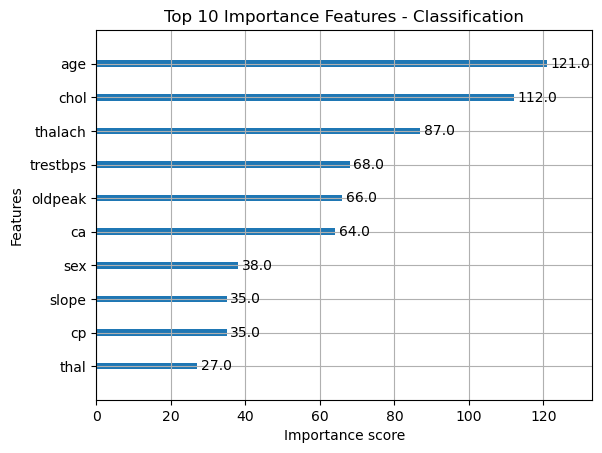

In [16]:
#Visualization
plot_importance(clf, max_num_features=10)
plt.title('Top 10 Importance Features - Classification')
plt.show()

---

## 5. Regression with XGBoost (California Housing Dataset)

---


In [17]:
#Load dataset
housing = fetch_california_housing()
housing_df = pd.DataFrame(housing.data, columns=housing.feature_names)
housing_df['target'] = housing.target

In [18]:
#Train-test split
X = housing_df.drop('target', axis=1)
y = housing_df['target']
X_train, X_test, y_train, y_test = train_test_split(X,y, test_size=0.2, random_state=42)

In [19]:
#Train regressor
reg = XGBRegressor(n_estimators=100, learning_rate=0.1, max_depth=4, random_state=42)
reg.fit(X_train, y_train)

XGBRegressor(base_score=None, booster=None, callbacks=None,
             colsample_bylevel=None, colsample_bynode=None,
             colsample_bytree=None, device=None, early_stopping_rounds=None,
             enable_categorical=False, eval_metric=None, feature_types=None,
             feature_weights=None, gamma=None, grow_policy=None,
             importance_type=None, interaction_constraints=None,
             learning_rate=0.1, max_bin=None, max_cat_threshold=None,
             max_cat_to_onehot=None, max_delta_step=None, max_depth=4,
             max_leaves=None, min_child_weight=None, missing=nan,
             monotone_constraints=None, multi_strategy=None, n_estimators=100,
             n_jobs=None, num_parallel_tree=None, ...)

In [20]:
#Predict and Evaluate
y_pred = reg.predict(X_test)
print(f'MAE: {mean_absolute_error(y_test, y_pred):.2f}')
print(f'RMSE: {np.sqrt(mean_absolute_error(y_test, y_pred)):.2f}')
print(f'R2 Score: {r2_score(y_test, y_pred):.2f}')

MAE: 0.35
RMSE: 0.59
R2 Score: 0.80


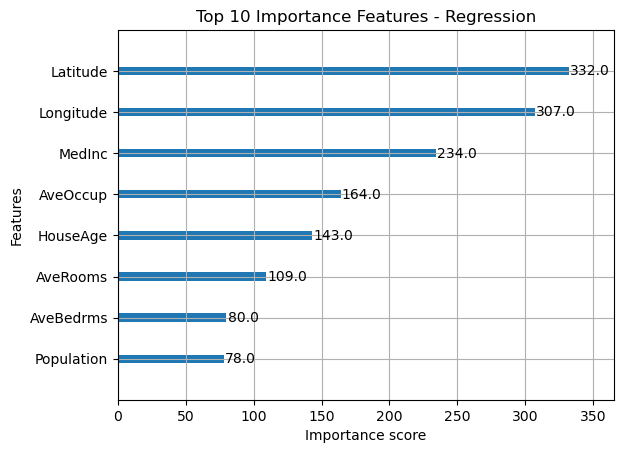

In [21]:
#Visualization
plot_importance(reg, max_num_features=10)
plt.title('Top 10 Importance Features - Regression')
plt.show()

---

## 6. Conclusion

✅ Learned the fundamentals of XGBoost and why it's a powerful ML technique.<br>
✅ Implemented XGBoost for both classification and regression tasks.<br>
✅ Used real-world datasets to demonstrate model capabilities.<br>
✅ Created robust visualizations of feature importance.<br>

🚀 This wraps up Day 37 of our Machine Learning Journey! 🚀